# Generate Performance Boxplots and Feature Importance Calculations from WandB Runs

## Import Required Libraries
Import necessary libraries such as `wandb`, `pandas`, `numpy`, `matplotlib`, and `seaborn`.

In [1]:
# Import Required Libraries
import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import wandb

# Setup Logging and Configuration
logging.basicConfig(
    format="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)
logger = logging.getLogger(__name__)

## Setup Logging and Configuration
Set up logging and define configurations such as WandB project name, sweep ID, and directories for saving results.

Here, looking at single-gene perturbation on P1000 somatic mutation dataset backbone. Essentially, we spiked in signal on a single gene (AR) and then assigned these samples to class 1.

In [ ]:
# Define WandB project and sweep details
PROJECT_NAME = "millergw/prostate_met_status"

# Define directories for saving results
SAVE_RESULTS_NAME = "p1000_somatic_germline"
FIGDIR = f"../figures/{SAVE_RESULTS_NAME}/"
RESULTS_DIR = f"../results/{SAVE_RESULTS_NAME}/"

# make directory if it doesn't exist
os.makedirs(os.path.join(FIGDIR), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR), exist_ok=True)

SWEEP_IDS = [
    "wbb2qw8r", # only keep model_type = "pnet"; contains train val test evaluation results 
    "wtn1xiau", # only keep model_type = "rf"
    # "5eiuaszx", # not using: exploring potential RF overfitting
    # "upk32i70" # added the one missing dataset combo; but this is actually equivalent dataset so not needed
]

# Figure parameters
figsize_tuple = (2.1, 2)
aspect_ratio_value = 1.7
cmap_style = "colorblind"

# NOTE: # there isn't ['germline_rare_common_lof'] bc there are no common LOF variants? So then why is there the somatic equivalent??
random_colorblind_split = {
    'somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense': '#0173B2',
    'somatic_amp somatic_del somatic_mut germline_rare_lof_missense': '#DE8F05',
    'somatic_amp somatic_del somatic_mut germline_rare_common_missense': '#029E73',
    'somatic_amp somatic_del somatic_mut germline_common_lof_missense': '#D55E00',
    'somatic_amp somatic_del somatic_mut germline_rare_lof': '#CC78BC',
    'somatic_amp somatic_del somatic_mut germline_rare_common_lof': '#CA9161',
    'somatic_amp somatic_del somatic_mut': '#949494',
    'germline_rare_common_lof_missense': '#FBAFE4',
    'germline_rare_common_missense': '#ECE133',
    'germline_rare_common_lof': '#56B4E9',
    'germline_common_lof_missense': '#E69F00',
    'germline_rare_lof': '#009E73',
    'germline_rare_lof_missense': '#F0E442'
}

warm_cool_colorblind_split = {
    # Somatic + Germline datasets (warm colors)
    'somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense': '#DE8F05',
    'somatic_amp somatic_del somatic_mut germline_rare_lof_missense': '#D55E00',
    'somatic_amp somatic_del somatic_mut germline_rare_common_missense': '#E69F00',
    'somatic_amp somatic_del somatic_mut germline_common_lof_missense': '#CA9161',
    'somatic_amp somatic_del somatic_mut germline_rare_lof': '#ECE133',
    'somatic_amp somatic_del somatic_mut germline_rare_common_lof': '#F0E442',
    'somatic_amp somatic_del somatic_mut': '#FBAFE4',

    # Germline-only groups (cool/neutral colors)
    'germline_rare_common_lof_missense': '#0173B2',
    'germline_rare_common_missense': '#029E73',
    'germline_rare_common_lof': '#56B4E9',
    'germline_common_lof_missense': '#009E73',
    'germline_rare_lof': '#CC78BC',
    'germline_rare_lof_missense': '#949494'
}

# germline lighter version
germline_lighter_colorblind_split = {
    'somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense': '#0173B2',
    'somatic_amp somatic_del somatic_mut germline_rare_lof_missense': '#DE8F05',
    'somatic_amp somatic_del somatic_mut germline_rare_common_missense': '#029E73',
    'somatic_amp somatic_del somatic_mut germline_common_lof_missense': '#D55E00',
    'somatic_amp somatic_del somatic_mut germline_rare_lof': '#CC78BC',
    'somatic_amp somatic_del somatic_mut germline_rare_common_lof': '#CA9161',
    'somatic_amp somatic_del somatic_mut': '#949494',
    'germline_rare_common_lof_missense': '#018ad6',
    'germline_rare_lof_missense': '#f1a934',
    'germline_rare_common_missense': '#02be8a',
    'germline_common_lof_missense': '#ff7101',
    'germline_rare_lof': '#dea7d3',
    'germline_rare_common_lof': '#d9b08e'
}

custom_colors = germline_lighter_colorblind_split

## Fetch WandB Runs and Performance Metrics (grouped by model_type, OR, and control_frequency)
Use the WandB API to fetch runs and extract performance metrics grouped by `model_type`, `odds_ratio`, `control_frequency`, and `n_features` for purposes of assessing the 'power curve' of the model. Store the results in a DataFrame.

In [3]:
# Initialize W&B API
api = wandb.Api()
# Collect runs from both sweeps
all_records = []
for sweep_id in SWEEP_IDS: 
    runs = api.runs(f"{PROJECT_NAME}", filters={"sweep": sweep_id})
    for run in runs: 
        if sweep_id == "wbb2qw8r": # only keep pnet
            if run.config.get("model_type") != "pnet":
                # skip this run
                continue
        elif sweep_id == "wtn1xiau":
            if run.config.get("model_type") != "rf":
                continue
        config = run.config
        summary = run.summary
        all_records.append({
            "run_id": run.id,
            "model_type": config.get("model_type"),
            "datasets": config.get("datasets"),
            "n_features": config.get("n_features"),
            "save_dir": config.get("save_dir").replace("../../results/", "/mnt/disks/gmiller_data1/pnet/results/"),
            "input_data_dir": config.get("input_data_dir"),
            # "target_f": os.path.join(config.get("perturbed_data_dir"), f"y_{config.get('perturbation_suffix')}.csv"),
        })
        for split in ["train", "validation", "test"]:
            all_records[-1][f"{split}_roc_auc_score"] = summary.get(f"{split}_roc_auc_score")
            all_records[-1][f"{split}_balanced_acc"] = summary.get(f"{split}_balanced_acc")
            all_records[-1][f"{split}_avg_precision"] = summary.get(f"{split}_average_precision_score")
        for split in ["validation", "test"]:
            corrected_save_path = config.get("save_dir").replace("../../results/", "/mnt/disks/gmiller_data1/pnet/results/")
            all_records[-1][f"{split}_feature_importances_path"] = os.path.join(corrected_save_path, f"{split}_gene_feature_importances.csv")
            all_records[-1][f"{split}_gene_importances_path"] = os.path.join(corrected_save_path, f"{split}_gene_importances.csv")



# Convert to a single DataFrame
df = pd.DataFrame(all_records)

print(df.datasets.value_counts())
# Filter out unintentional equality (bc no common LOF variants exist), germline_common_lof_missense (=germline_common_missense) and germline_rare_common_lof (= germline_rare_lof)
df = df[df["datasets"] != "somatic_amp somatic_del somatic_mut germline_rare_common_lof"]

# TODO: rename germline_common_lof_missense to germline_common_missense since these are actually the same dataset and do not contain any common LOF variants
# TODO: would also need to update the color mapping for the datasets
# df = df.replace({"datasets": {"germline_common_lof_missense": "germline_common_missense",
#                               "somatic_amp somatic_del somatic_mut germline_common_lof_missense": "somatic_amp somatic_del somatic_mut germline_common_missense"}})

# Average over seeds
group_by_cols = ["model_type", "datasets"]

# Add a counts column for each group
df_counts = df.groupby(group_by_cols).size().reset_index(name="count")

# Average over seeds
df_avg = df.groupby(group_by_cols, as_index=False).mean()

# Merge counts into df_avg
df_avg = df_avg.merge(df_counts, on=group_by_cols)
df_avg

somatic_amp somatic_del somatic_mut germline_rare_common_missense        10
somatic_amp somatic_del somatic_mut germline_rare_common_lof             10
somatic_amp somatic_del somatic_mut germline_common_lof_missense         10
somatic_amp somatic_del somatic_mut germline_rare_lof_missense           10
somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense    10
germline_rare_common_lof_missense                                        10
somatic_amp somatic_del somatic_mut germline_rare_lof                    10
germline_common_lof_missense                                             10
germline_rare_lof_missense                                               10
germline_rare_common_missense                                            10
germline_rare_lof                                                        10
somatic_amp somatic_del somatic_mut                                      10
Name: datasets, dtype: int64


,model_type,datasets,train_roc_auc_score,train_balanced_acc,train_avg_precision,validation_roc_auc_score,validation_balanced_acc,validation_avg_precision,test_roc_auc_score,test_balanced_acc,test_avg_precision,count
0,pnet,germline_common_lof_missense,0.584294,0.500000,0.390022,0.456089,0.500000,0.340877,0.586012,0.500000,0.422931,5
1,pnet,germline_rare_common_lof_missense,0.660668,0.507307,0.507553,0.575878,0.507143,0.532269,0.576190,0.503125,0.438140,5
2,pnet,germline_rare_common_missense,0.591522,0.500000,0.399066,0.457963,0.500000,0.329065,0.566964,0.500000,0.394304,5
3,pnet,germline_rare_lof,0.666407,0.500833,0.523576,0.569906,0.500000,0.545670,0.585516,0.500000,0.452610,5
4,pnet,germline_rare_lof_missense,0.672715,0.505224,0.525354,0.597717,0.503571,0.541574,0.564683,0.503125,0.421933,5
5,pnet,somatic_amp somatic_del somatic_mut,0.991408,0.938839,0.986377,0.918033,0.807670,0.856163,0.944742,0.845139,0.915367,5
6,pnet,somatic_amp somatic_del somatic_mut germline_c...,0.994533,0.951375,0.991202,0.941569,0.811710,0.884595,0.940873,0.812302,0.912409,5
7,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.992304,0.926693,0.987177,0.929508,0.809778,0.876004,0.927282,0.810714,0.907208,5
8,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.992820,0.934547,0.988681,0.932553,0.814988,0.872603,0.933929,0.798214,0.896643,5
9,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.993388,0.926084,0.989224,0.932904,0.806206,0.881054,0.929663,0.807540,0.900480,5


In [40]:
# Define the prevalence of the positive class (equal to random model's AP or AUPRC)
p1000_metastatic_prevalence = pd.read_csv(os.path.join(df.input_data_dir[0], "y.csv"), index_col=0)['is_met'].mean()
print(f"Prevalence of 1s (metastatic samples): {p1000_metastatic_prevalence:.2%}")

Prevalence of 1s (metastatic samples): 31.81%


In [4]:
df.datasets.value_counts()

somatic_amp somatic_del somatic_mut germline_rare_common_missense        10
somatic_amp somatic_del somatic_mut germline_common_lof_missense         10
somatic_amp somatic_del somatic_mut germline_rare_lof_missense           10
somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense    10
germline_rare_common_lof_missense                                        10
somatic_amp somatic_del somatic_mut germline_rare_lof                    10
germline_common_lof_missense                                             10
germline_rare_lof_missense                                               10
germline_rare_common_missense                                            10
germline_rare_lof                                                        10
somatic_amp somatic_del somatic_mut                                      10
Name: datasets, dtype: int64

In [5]:
print(df.shape)
df.head()

(110, 19)


,run_id,model_type,datasets,n_features,save_dir,input_data_dir,train_roc_auc_score,train_balanced_acc,train_avg_precision,validation_roc_auc_score,validation_balanced_acc,validation_avg_precision,test_roc_auc_score,test_balanced_acc,test_avg_precision,validation_feature_importances_path,validation_gene_importances_path,test_feature_importances_path,test_gene_importances_path
0,8re92263,pnet,somatic_amp somatic_del somatic_mut germline_r...,None,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.996500,0.977396,0.994994,0.931499,0.869731,0.848545,0.940476,0.781002,0.918421,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...
1,qslpvjz8,pnet,somatic_amp somatic_del somatic_mut germline_r...,None,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.989884,0.907370,0.984250,0.939696,0.796838,0.874320,0.946429,0.749752,0.899266,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...
2,69fg9ils,pnet,somatic_amp somatic_del somatic_mut germline_r...,None,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.993232,0.952240,0.989133,0.930913,0.806499,0.891101,0.927579,0.874752,0.892665,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...
3,5semzsjo,pnet,somatic_amp somatic_del somatic_mut germline_r...,None,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.989804,0.900157,0.983811,0.923302,0.761124,0.851661,0.923115,0.765377,0.858441,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...
4,ct0hrfcz,pnet,somatic_amp somatic_del somatic_mut germline_r...,None,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.994677,0.935573,0.991216,0.937354,0.840749,0.897387,0.932044,0.820188,0.914420,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...,/mnt/disks/gmiller_data1/pnet/results/pnet_som...


## helper functions

In [49]:
def smart_ticklabels(labels):
    return [f"{int(l)}" if float(l).is_integer() else f"{l:.1f}" for l in labels]

def get_smart_odds_ratio_labels(axessubplot_object):
    """Expects type <class 'matplotlib.axes._subplots.AxesSubplot'> as input"""
    smart_yticks = smart_ticklabels([float(l.get_text()) for l in axessubplot_object.get_yticklabels()])
    return smart_yticks

def get_feature_matrix(datasets, features):
    "Build upset-style indicator matrix to accompany box plots"
    logger.debug("features:", features)
    for dataset in datasets:
        logger.debug(f"working on {dataset}: {[int(feature in dataset) for feature in features]}")
    
    indicator_df = pd.DataFrame({
        feature: [int(feature in dataset) for dataset in datasets]
        for feature in features
    }, index=datasets)

    return indicator_df


def generate_fake_data(datasets):
    np.random.seed(123)
    data = []
    for i, dataset in enumerate(datasets):
        for _ in range(20):
            value = np.random.normal(loc=5 + i, scale=1.0)
            data.append({"datasets": dataset, "value": value})
    return pd.DataFrame(data)


def plot_boxplot(data, x_name="datasets", y_name="value", color_map=None, ax=None, 
                 no_x_labels=False, showfliers=True, dataset_order=None):
    """
    Plot a seaborn boxplot with optional custom color mapping.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    
    valid_order = get_valid_group_order(data, dataset_order, group_col=x_name) if dataset_order else None
    sns.boxplot(data=data, x=x_name, y=y_name, ax=ax, showfliers=showfliers, 
                palette=color_map if color_map else None,
                order=valid_order
    )
    if not showfliers:
        sns.stripplot(data=data, x=x_name, y=y_name, ax=ax, color="black", jitter=0.2, alpha=0.3,
                    order=valid_order
                    )
    if no_x_labels:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    return ax



def plot_feature_matrix(feature_matrix, x_labels, ax=None, fig_size=(10,2)):
    """
    Plot a binary feature matrix below a boxplot using scatter plot markers.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=fig_size)
    
    x_positions = list(range(len(x_labels)))
    feature_matrix = feature_matrix.loc[x_labels] # ensure order matches

    features = feature_matrix.columns

    for i, feature in enumerate(features):
        y = [len(features) - i - 1] * len(x_labels)  # Flip Y order
        values = feature_matrix[feature].tolist()
        ax.scatter(
            x_positions,
            y,
            c=values,
            cmap="Greys",
            vmin=0, vmax=1,   # force full contrast
            marker="o",
            s=100,
            edgecolor='black'
        )
    
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features[::-1])  # Reverse to match flipped Y
    ax.set_xticks([])  # Hide x-axis labels
    ax.set_ylim(-0.5, len(features) - 0.5)
    ax.set_xlim(-0.5, len(x_labels) - 0.5)
    return ax



def plot_boxplot_with_features(data, datasets, feature_matrix, color_map=None, dataset_order=None,
                                x_name="datasets", y_name="value", title="Boxplot with UpSet-Style Feature Labels",
                                figsize_tuple=(6, 3), fig_ratio=[4,1]):

    # valid data order: restrict the ordered list to the groups we actually have in our data; default to datasets
    valid_dataset_order = get_valid_group_order(data, dataset_order, group_col=x_name) if dataset_order else datasets

    fig, (ax_box, ax_matrix) = plt.subplots(
        2, 1, figsize=figsize_tuple, gridspec_kw={"height_ratios": fig_ratio}, sharex=True
    )

    plot_boxplot(data, x_name, y_name, color_map=color_map, ax=ax_box, no_x_labels=True, dataset_order=valid_dataset_order)
    ax_box.set_title(title)

    ax_matrix = plot_feature_matrix(feature_matrix, x_labels=valid_dataset_order, ax=ax_matrix)

    for i in range(len(valid_dataset_order)):
        ax_box.axvline(x=i, color='lightgray', linestyle='--', linewidth=1, zorder=0)
        ax_matrix.axvline(x=i, color='lightgray', linestyle='--', linewidth=1, zorder=0)

    plt.tight_layout()
    plt.show()


def get_group_ordered_by_statistic(df, group_col_name, order_col_name='auc', stat="median", ascending=False):
    if stat=="mean":
        # Calculate mean for each dataset
        sorted_df = df.groupby(group_col_name)[order_col_name].mean().sort_values(ascending=ascending)
    elif stat=="median":
        # Calculate median for each dataset
        sorted_df = df.groupby(group_col_name)[order_col_name].median().sort_values(ascending=ascending)
    else:
        print("TODO: not implemented")
        return
    # Order the datasets by descending mean AUC
    group_order = sorted_df.index.tolist()
    return group_order

def get_valid_group_order(df, group_order, group_col="datasets"):
    """
    Return a filtered dataset order that includes only the group_col values present in df.
    """
    available = df[group_col].unique().tolist()
    return [d for d in group_order if d in available]


def plot_model_comparison_with_features(df, eval_set, feature_matrix, color_map=None, dataset_order=None,
                                        figsize_tuple=(8,6), fig_ratio=[6,6,3], shareY=True, 
                                        title="Performance boxplots", random_performance_value=None, setMinYToRandomPerformance=False):
    metric_col = f"{eval_set}_avg_precision"
    datasets = df["datasets"].unique().tolist()
    valid_dataset_order = get_valid_group_order(df, dataset_order, group_col="datasets") if dataset_order else datasets

    # Split data
    df_pnet = df[df["model_type"] == "pnet"]
    df_rf = df[df["model_type"] == "rf"]

    # Set up figure
    fig, (ax_pnet, ax_rf, ax_matrix) = plt.subplots(
        3, 1,
        figsize=figsize_tuple,
        gridspec_kw={"height_ratios": fig_ratio},
        sharex=True,
    )

    # Plot PNet
    plot_boxplot(
        data=df_pnet,
        x_name="datasets",
        y_name=metric_col,
        color_map=color_map,
        ax=ax_pnet,
        dataset_order=valid_dataset_order
    )
    ax_pnet.set_title("model = P-NET")
    
    # Plot RF
    plot_boxplot(
        data=df_rf,
        x_name="datasets",
        y_name=metric_col,
        color_map=color_map,
        ax=ax_rf,
        dataset_order=valid_dataset_order
    )
    ax_rf.set_title("model = Random Forest")

    if shareY:
        # Sync y-axis limits between ax_pnet and ax_rf
        y_min = min(ax_pnet.get_ylim()[0], ax_rf.get_ylim()[0])
        if setMinYToRandomPerformance and random_performance_value is not None:
            y_min = min(y_min, random_performance_value-0.03)  # add a little buffer below the random performance line
        y_max = max(ax_pnet.get_ylim()[1], ax_rf.get_ylim()[1])
        ax_pnet.set_ylim(y_min, y_max)
        ax_rf.set_ylim(y_min, y_max)

    # add horizontal line to represent random performance
    if random_performance_value is not None:
        ax_pnet.axhline(y=random_performance_value, linestyle='--', color='gray', linewidth=1)
        ax_rf.axhline(y=random_performance_value, linestyle='--', color='gray', linewidth=1)

    # # Draw vertical lines for each dataset to draw the eye to the x-axis legend
    # for i in range(len(datasets)):
    #     ax_pnet.axvline(x=i, color='lightgray', linestyle='--', linewidth=1, zorder=0)
    #     ax_rf.axvline(x=i, color='lightgray', linestyle='--', linewidth=1, zorder=0)
    #     ax_matrix.axvline(x=i, color='lightgray', linestyle='--', linewidth=1, zorder=0)


    # Plot shared feature matrix
    plot_feature_matrix(feature_matrix, x_labels=valid_dataset_order, ax=ax_matrix)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


## Performance boxplot of P-NET and RF

### fake data

In [50]:
# Define all 13 datasets
datasets_all = [
    'somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense',
    'somatic_amp somatic_del somatic_mut germline_rare_lof_missense',
    'somatic_amp somatic_del somatic_mut germline_rare_common_missense',
    'somatic_amp somatic_del somatic_mut germline_common_lof_missense',
    'somatic_amp somatic_del somatic_mut germline_rare_lof',
    'somatic_amp somatic_del somatic_mut germline_rare_common_lof',
    'somatic_amp somatic_del somatic_mut',
    'germline_rare_common_lof_missense',
    'germline_rare_common_missense',
    'germline_rare_common_lof',
    'germline_common_lof_missense',
    'germline_rare_lof',
    'germline_rare_lof_missense'
]

features = ['somatic', 'rare', 'common', 'lof', 'missense']
feature_matrix = get_feature_matrix(datasets_all, features)
data = generate_fake_data(datasets_all) # needs a shared group col w/the feature_matrix, e.g. "datasets" and col containing the values you want to plot
# plot_boxplot_with_features(data, datasets_all, feature_matrix, color_map=custom_colors)

### P1000 data

### boxplots on all dataset combos combined)

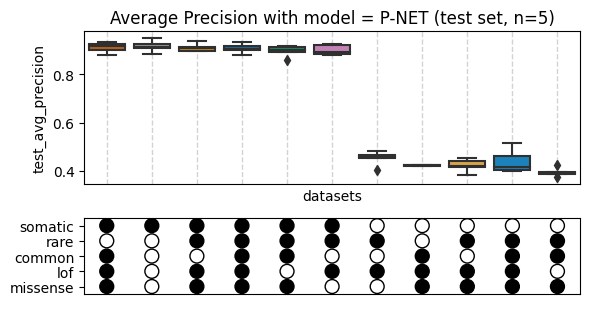

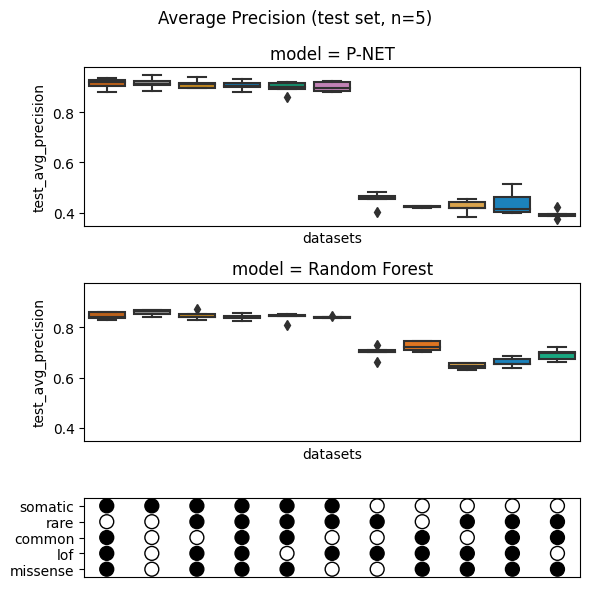

In [59]:
eval_set = "test"
metric_col = f"{eval_set}_avg_precision"
df_pnet = df[df["model_type"] == "pnet"]
df_rf = df[df["model_type"] == "rf"]
datasets = df['datasets'].unique().tolist()

# force datasets to follow this order (decreasing median(metric) in P-NET runs)
dataset_order = get_group_ordered_by_statistic(df_pnet, group_col_name="datasets", stat="median", 
                                            order_col_name=metric_col, ascending=False)


features = ['somatic', 'rare', 'common', 'lof', 'missense']
feature_matrix = get_feature_matrix(datasets, features)

plot_boxplot_with_features(df_pnet, datasets, feature_matrix, color_map=custom_colors, 
                           y_name=metric_col, x_name="datasets",
                           dataset_order=dataset_order,
                           title=f"Average Precision with model = P-NET ({eval_set} set, n=5)", 
                           figsize_tuple=(6, 3.2), fig_ratio=[2, 1])

plot_model_comparison_with_features(df, eval_set, feature_matrix, color_map=custom_colors, 
                                    dataset_order=dataset_order,
                                    figsize_tuple=(6,6), fig_ratio=[6, 6, 3], 
                                    title=f"Average Precision ({eval_set} set, n=5)")

### boxplots: germline only

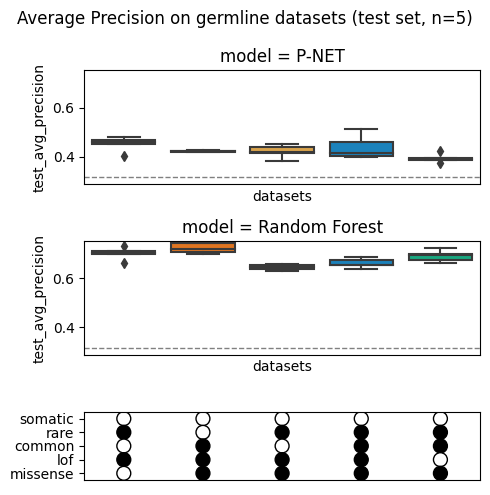

In [60]:
metric_col = f"{eval_set}_avg_precision"
df_germline_only = df[~df["datasets"].str.contains("somatic")]
datasets = df_germline_only['datasets'].unique().tolist()


features = ['somatic', 'rare', 'common', 'lof', 'missense']
feature_matrix = get_feature_matrix(datasets, features)

plot_model_comparison_with_features(df_germline_only, eval_set, feature_matrix, color_map=custom_colors, 
                                    dataset_order=dataset_order,
                                    figsize_tuple=(5,5), fig_ratio=[5, 5, 3], 
                                    title=f"Average Precision on germline datasets ({eval_set} set, n=5)",
                                    random_performance_value=p1000_metastatic_prevalence,
                                    setMinYToRandomPerformance=True)

### boxplot: somatic:germline combos

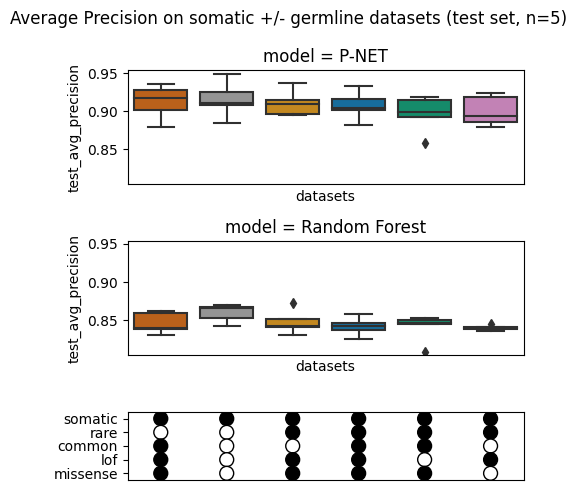

In [61]:
metric_col = f"{eval_set}_avg_precision"
df_combos = df[df["datasets"].str.contains("somatic")]
datasets = df_combos['datasets'].unique().tolist()


features = ['somatic', 'rare', 'common', 'lof', 'missense']
feature_matrix = get_feature_matrix(datasets, features)

plot_model_comparison_with_features(df_combos, eval_set, feature_matrix, color_map=custom_colors, 
                                    dataset_order=dataset_order,
                                    figsize_tuple=(5,5), fig_ratio=[5, 5, 3], 
                                    title=f"Average Precision on somatic +/- germline datasets ({eval_set} set, n=5)",
                                    random_performance_value=p1000_metastatic_prevalence)

# P-NET feature rankings
- top 10 gene features for each "datasets" value?
- table of top 5 genes, then ellipses, then BRCA2 at appropriate rank
    - first: get top 10 genes per model, their rank, absolute imp
    - second: get BRCA2 rank, abs imp
    - third: select the "datasets" values of interest. Proposed: somatic only, one germline only with low BRCA2 rank, som:germ combo equivalent
    - finally: will probably need to manually create figure

In [11]:
def load_feature_importances(importances_path):
    """
    Load feature importance data from a CSV file.

    Args:
        importances_path (str): Path to the feature importance file.

    Returns:
        pd.DataFrame: DataFrame of feature importances.
    """
    if not os.path.exists(importances_path):
        raise FileNotFoundError(f"File not found: {importances_path}")
    logger.debug(f"Loading feature importances from {importances_path}")
    return pd.read_csv(importances_path).set_index('Unnamed: 0')


def process_importances(imps, response_df):
    """
    Process feature importances by joining with response data and calculating differences between sample classes.
    This function computes the mean feature importances for each response class and then calculates the difference between them.
    The result is a Series of feature importance differences.

    Args:
        imps (pd.DataFrame): Feature importance DataFrame.
        response_df (pd.DataFrame): Response variable DataFrame.

    Returns:
        pd.Series: Processed feature importance differences.
    """
    logger.debug(f"head of imps.join(response_df).groupby('response').mean(): {imps.join(response_df).groupby('response').mean().head()}")
    logger.debug(f"shape of imps.join(response_df).groupby('response').mean(): {imps.join(response_df).groupby('response').mean().shape}")
    return imps.join(response_df).groupby('response').mean().diff(axis=0).iloc[1]

def load_response_variable(response_path='../../pnet_germline/data/pnet_database/prostate/processed/response_paper.csv'):
    # Load the response variable DataFrame
    response_df = pd.read_csv(response_path)
    response_df.rename(columns={'id': "Tumor_Sample_Barcode"}, inplace=True)
    response_df.set_index('Tumor_Sample_Barcode', inplace=True)
    return response_df

def process_feature_importances(df_feature_importance_paths, response_df, importance_path_column='feature_importances_path', group_identifier_column='group_identifier'):
    """
    Process feature importance data for multiple runs and group by dataset.

    Args:
        df_feature_importance_paths (pd.DataFrame): DataFrame with feature importance paths and dataset info.
        response_df (pd.DataFrame): Response variable DataFrame.

    Returns:
        tuple: Dictionaries of DataFrames for feature importances and ranks grouped by the input datasets used in the model.
    """
    imps_by_key = {}
    ranks_by_key = {}

    logger.info(f"Processing feature importances for {df_feature_importance_paths.shape[0]} runs...")
    for _, row in df_feature_importance_paths.iterrows():
        try:
            # Load feature importances from the specified path
            imps = load_feature_importances(row[importance_path_column])
            processed_imps = process_importances(imps, response_df)
            ranks = processed_imps.abs().rank(ascending=False)

            key = row[group_identifier_column]
            imps_by_key.setdefault(key, []).append(processed_imps)
            ranks_by_key.setdefault(key, []).append(ranks)
        except FileNotFoundError as e:
            print(e)
            continue

    df_imps_by_key = {key: pd.DataFrame(imps_list) for key, imps_list in imps_by_key.items()}
    df_ranks_by_key = {key: pd.DataFrame(ranks_list) for key, ranks_list in ranks_by_key.items()}
    return df_imps_by_key, df_ranks_by_key



def extract_top_features_from_df(df_per_dataset, top_n=10, keep_smallest_n=True, index_label=None):
    """
    Extract the top N features by rank for each dataset.

    Args:
        df_per_dataset (dict): Dictionary containing feature-level pd DataFrames for each dataset.
        top_n (int): Number of top features to extract.
        keep_smallest_n (bool): Whether to sort in ascending order (lower rank is better).

    Returns:
        pd.DataFrame: DataFrame containing the top N features for each dataset.
    """
    top_features_df = pd.DataFrame()

    # Iterate over the dictionary to calculate top features
    for dataset, df in df_per_dataset.items():
        # Calculate the mean rank for each feature and select the top N
        top_features = df.mean(axis=0).sort_values(ascending=keep_smallest_n)[:top_n]
        # Add the top features as a column to the DataFrame
        top_features_df[dataset] = top_features.index

    # Set the index of the DataFrame to be 1 through top_n
    top_features_df.index = range(1, top_n + 1)

    if index_label is not None:
        top_features_df.index.name = index_label

    return top_features_df

def build_runwise_gene_importance_rank_df(df, response_df, importance_path_column='gene_importances_path', top_n=10):
    """
    Build a DataFrame summarizing gene importance and rank for each run.

    For each run in df, this function:
      - Loads the gene importances and computes the class-difference importance vector.
      - Computes the absolute rank of each gene (lower rank = more important).
      - Restricts to the top_n ranked genes.
      - For each of those genes, records run ID, datasets column (as gene_perturbation_group), gene name, rank, and importance.

    Args:
        df (pd.DataFrame): DataFrame with one row per run, containing columns for run_id, datasets, and path to gene importances.
        response_df (pd.DataFrame): DataFrame with sample responses, indexed by sample name, with column 'response'.
        importance_path_column (str): Column name in df with the path to the gene importances CSV.
        top_n (int): Number of top-ranked genes to retain per run.

    Returns:
        pd.DataFrame: DataFrame with columns [run_id, gene_perturbation_group, gene, rank, imp], 
                      where rank and imp are the rank and importance for each gene.
    """
    logger.info(f"For each of the {df.shape[0]} model runs, extracting top {top_n} ranked genes based on absolute importance")
    records = []

    for idx, row in df.iterrows():
        run_id = row.get("run_id") or row.get("wandb_run_id") or idx
        datasets = row.get("datasets", "unknown_dataset")
        logger.debug(f"Processing run {run_id} with row: {row.to_dict()}")

        try:
            imps = load_feature_importances(row[importance_path_column])  # DataFrame: samples x genes
            processed_imps = process_importances(imps, response_df)       # Series: gene -> score
            ranks = processed_imps.abs().rank(ascending=False)

            top_genes = ranks.nsmallest(top_n).index

            for gene in top_genes:
                records.append({
                    "run_id": run_id,
                    "datasets": datasets,
                    "gene": gene,
                    "rank": ranks[gene],
                    "importance": processed_imps[gene],
                    "absolute_importance": abs(processed_imps[gene]),
                })

        except Exception as e:
            logger.warning(f"Skipping run {run_id} due to error: {e}")
            continue

    return pd.DataFrame.from_records(records)


def build_datasetwise_gene_importance_rank_df_old(df, response_df, importance_path_column='gene_importances_path', top_n=10):
    """ Does average-then-rank WARNING
    Build a DataFrame summarizing average gene importance and rank across runs, grouped by datasets.

    For each dataset group in df, this function:
      - Loads and processes gene importances from all runs in that dataset group.
      - Averages signed and absolute importances across runs.
      - Computes ranks based on mean absolute importance.
      - Selects top_n genes per group.

    Args:
        df (pd.DataFrame): DataFrame with one row per run, containing columns for run_id, datasets, and gene importance path.
        response_df (pd.DataFrame): DataFrame with sample responses, indexed by sample name, with column 'response'.
        importance_path_column (str): Column name in df with the path to the gene importances CSV.
        top_n (int): Number of top-ranked genes to retain per dataset group.

    Returns:
        pd.DataFrame: DataFrame with columns [gene_perturbation_group, gene, rank, imp, absolute_importance],
                      where rank and imp are computed from average values across runs.
    """
    logger.info(f"Aggregating gene importances across {df.shape[0]} runs grouped by dataset")

    # Store processed importance vectors for each dataset group
    grouped_imps = {}

    for idx, row in df.iterrows():
        run_id = row.get("run_id") or row.get("wandb_run_id") or idx
        datasets = row.get("datasets", "unknown_dataset")
        logger.debug(f"Processing run {run_id} from dataset group {datasets}")

        try:
            imps = load_feature_importances(row[importance_path_column])  # DataFrame: samples x genes
            processed = process_importances(imps, response_df)            # Series: gene -> score

            if datasets not in grouped_imps:
                grouped_imps[datasets] = []

            grouped_imps[datasets].append(processed)

        except Exception as e:
            logger.warning(f"Skipping run {run_id} due to error: {e}")
            continue

    # Aggregate and rank
    records = []

    for dataset_group, imps_list in grouped_imps.items():
        logger.info(f"Computing averages for dataset group: {dataset_group}")

        # Combine all processed importance Series into a DataFrame (runs x genes)
        imp_df = pd.DataFrame(imps_list)
        mean_imp = imp_df.mean()
        mean_abs_imp = imp_df.abs().mean()

        ranks = mean_abs_imp.rank(ascending=False)

        top_genes = ranks.nsmallest(top_n).index

        for gene in top_genes:
            records.append({
                "datasets": dataset_group,
                "gene": gene,
                "rank": ranks[gene],
                "imp": mean_imp[gene],
                "absolute_importance": mean_abs_imp[gene],
            })

    return pd.DataFrame.from_records(records)

def build_datasetwise_gene_importance_rank_df(
    df,
    response_df,
    importance_path_column: str = "gene_importances_path",
    top_n: int = 10,
):
    """
    Aggregate gene importances **run-wise first, then average ranks across runs**.

    Workflow per dataset group
    --------------------------
    1. For each run:
         • load per-sample importances
         • collapse to a single importance score per gene via `process_importances`
         • convert those |scores| to ranks **within that run**
    2. Stack the per-run rank vectors into a DataFrame (runs × genes) and
       take the **mean rank** for every gene.
    3. Select the `top_n` genes with the smallest mean rank.
       Also report the mean signed importance and mean absolute importance
       (useful for interpretation even though ranking is done first).

    Returns
    -------
    pd.DataFrame with columns:
        datasets  : dataset group key
        gene      : gene symbol / feature name
        rank      : *mean* rank across runs (lower = better)
        imp       : mean signed importance across runs
        absolute_importance : mean absolute importance across runs
    """
    logger.info(
        f"Aggregating gene importances across {df.shape[0]} runs "
        f"grouped by dataset (rank-then-average)"
    )

    # Collect one Series-of-scores per run, keyed by dataset group
    grouped_scores: dict[str, list[pd.Series]] = {}

    for idx, row in df.iterrows():
        run_id   = row.get("run_id") or row.get("wandb_run_id") or idx
        datasets = row.get("datasets", "unknown_dataset")

        try:
            imps = load_feature_importances(row[importance_path_column])      # samples × genes
            scores = process_importances(imps, response_df)                   # gene → score

            grouped_scores.setdefault(datasets, []).append(scores)

        except Exception as e:
            logger.warning(f"Skipping run {run_id}: {e}")
            continue

    records = []

    for dataset_group, score_list in grouped_scores.items():
        logger.info(f"Computing rank-then-average for dataset group: {dataset_group}")

        # (runs × genes) DataFrame of *scores*
        score_df = pd.DataFrame(score_list)

        # ── 1. Per-run ranking on |score| ───────────────────────────────────────
        per_run_ranks = score_df.abs().rank(axis=1, ascending=False)

        # ── 2. Average across runs ─────────────────────────────────────────────
        mean_rank      = per_run_ranks.mean()    
        recomputed_rank   = mean_rank.rank(ascending=True)    # 1 = best, 2 = next…
        # smaller = more important
        mean_imp       = score_df.mean()                   # signed
        mean_abs_imp   = score_df.abs().mean()

        # ── 3. Pick top_n genes by mean rank ──────────────────────────────────
        top_genes = recomputed_rank.nsmallest(top_n).index

        for gene in top_genes:
            records.append(
                {
                    "datasets": dataset_group,
                    "gene": gene,
                    "rank": float(recomputed_rank[gene]),
                    "importance": float(mean_imp[gene]),
                    "absolute_importance": float(mean_abs_imp[gene]),
                }
            )

    return pd.DataFrame.from_records(records)


In [12]:
logger.info("Get the feature importances and ranks for each dataset combination")
eval_set = "test"
importance_path = f'{eval_set}_feature_importances_path' # f'{eval_set}_gene_importances_path
importance_path = f'{eval_set}_gene_importances_path' # f'{eval_set}_gene_importances_path
logger.info(f"Filter to runs where model_type is 'pnet'")
df_filt = df[df["model_type"]=="pnet"]
response_f = "/mnt/disks/gmiller_data1/pnet_germline/data/pnet_database/prostate/processed/response_paper.csv"
response_df = load_response_variable(response_f)
# df_feature_importance_paths = fetch_feature_importance_paths(runs, GROUP_NAME)

# # gene x modality
# df_imps_by_key, df_ranks_by_key = process_feature_importances(df_feature_importance_paths)

# gene 
df_imps_by_key, df_ranks_by_key = process_feature_importances(df_filt, response_df, 
                                                              importance_path_column=importance_path, # 
                                                              group_identifier_column="datasets")

2025-07-30 00:36:10 INFO     [__main__] Get the feature importances and ranks for each dataset combination
2025-07-30 00:36:10 INFO     [__main__] Filter to runs where model_type is 'pnet'
2025-07-30 00:36:10 INFO     [__main__] Processing feature importances for 55 runs...


### TODO: importantly, this gives slightly different top 10 lists compared to my code for getting df_ranks_by_key using process_feature_importances.
This is because rank(mean(x)) != mean(rank(x)) in general. If I compute rank and then average (aka mean(rank(x)))

Check: I think that I used something similar to build_datasetwise_gene_importance_rank_df for my 1D and 2D simulation analyses. In that case, probably wise to do analogous version here on the empirical results. Similar for aggregate_topk_recovery in 2D simulation: this is rank-then-average.

The notion of "top-K recovery" is inherently rank-based. You're interested in whether known signal genes are ranked high — not how large their scores are.

Averaging importances before ranking (i.e., average-then-rank) would obscure per-run behavior. **A gene might rank high on average because it’s very strong in a few runs, but that doesn’t mean it is consistently recovered in any individual top-K.**

| Desired interpretation                                                                        | Recommended approach                                                                                    |
| --------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------- |
| “Which genes are *consistently* near the top, run-after-run?”                                 | **Rank-then-average** (your first pipeline). A feature must earn good rank in many runs to stay on top. |
| “Which genes have the *largest average magnitude* of effect, even if they occasionally drop?” | **Average-then-rank** (the second pipeline aka build_datasetwise_gene_importance_rank_df). It rewards high overall contribution, not consistency.     |



In [13]:
# per_run_imps_df = build_runwise_gene_importance_rank_df(df_filt, response_df, importance_path_column=importance_path)
per_data_combo_imps_df = build_datasetwise_gene_importance_rank_df(df_filt, response_df, importance_path_column=importance_path)


2025-07-30 00:36:23 INFO     [__main__] Aggregating gene importances across 55 runs grouped by dataset (rank-then-average)
2025-07-30 00:36:35 INFO     [__main__] Computing rank-then-average for dataset group: somatic_amp somatic_del somatic_mut germline_rare_common_missense
2025-07-30 00:36:35 INFO     [__main__] Computing rank-then-average for dataset group: somatic_amp somatic_del somatic_mut germline_common_lof_missense
2025-07-30 00:36:35 INFO     [__main__] Computing rank-then-average for dataset group: somatic_amp somatic_del somatic_mut germline_rare_lof_missense
2025-07-30 00:36:35 INFO     [__main__] Computing rank-then-average for dataset group: somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense
2025-07-30 00:36:35 INFO     [__main__] Computing rank-then-average for dataset group: germline_rare_common_lof_missense
2025-07-30 00:36:35 INFO     [__main__] Computing rank-then-average for dataset group: somatic_amp somatic_del somatic_mut germline_rare_lof
202

In [14]:
per_data_combo_imps_df.shape

(110, 5)

In [15]:
per_data_combo_imps_df.datasets.unique().tolist()

['somatic_amp somatic_del somatic_mut germline_rare_common_missense',
 'somatic_amp somatic_del somatic_mut germline_common_lof_missense',
 'somatic_amp somatic_del somatic_mut germline_rare_lof_missense',
 'somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense',
 'germline_rare_common_lof_missense',
 'somatic_amp somatic_del somatic_mut germline_rare_lof',
 'germline_common_lof_missense',
 'germline_rare_lof_missense',
 'germline_rare_common_missense',
 'germline_rare_lof',
 'somatic_amp somatic_del somatic_mut']

In [62]:
dsets_to_visualize = [
     'somatic_amp somatic_del somatic_mut',
     'somatic_amp somatic_del somatic_mut germline_rare_lof',
     'germline_rare_lof',
     'germline_rare_common_lof',
     'germline_rare_common_lof_missense',
     'somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense'
     
]
per_data_combo_imps_df.style.format({
    "importance": "{:.2f}",
    "absolute_importance": "{:.2f}",
    "rank": "{:.2f}"
})

per_data_combo_imps_df[per_data_combo_imps_df["datasets"] == dsets_to_visualize[4]].style.format({
    "importance": "{:.2f}",
    "absolute_importance": "{:.2f}",
    "rank": "{:.2f}"
})

,datasets,gene,rank,importance,absolute_importance
40,germline_rare_common_lof_missense,BRCA2,1.00,0.01,0.01
41,germline_rare_common_lof_missense,ATM,2.00,0.01,0.01
42,germline_rare_common_lof_missense,HLA-A,3.00,-0.00,0.00
43,germline_rare_common_lof_missense,CNBD1,4.00,-0.00,0.00
44,germline_rare_common_lof_missense,MSH2,5.00,0.00,0.00
45,germline_rare_common_lof_missense,SBDS,6.00,-0.00,0.00
46,germline_rare_common_lof_missense,ERCC2,7.00,-0.00,0.00
47,germline_rare_common_lof_missense,TET2,8.00,0.00,0.00
48,germline_rare_common_lof_missense,ECT2L,9.50,-0.00,0.00
49,germline_rare_common_lof_missense,APC,9.50,-0.00,0.00


### suppl figure: top 10 genes by dataset group

,somatic_amp somatic_del somatic_mut germline_rare_lof_missense,somatic_amp somatic_del somatic_mut germline_rare_lof,somatic_amp somatic_del somatic_mut germline_rare_common_missense,somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense,somatic_amp somatic_del somatic_mut germline_common_lof_missense,somatic_amp somatic_del somatic_mut,germline_rare_lof_missense,germline_rare_lof,germline_rare_common_missense,germline_rare_common_lof_missense,germline_common_lof_missense
rank,,,,,,,,,,,
1,AR,AR,AR,AR,AR,AR,BRCA2,BRCA2,MITF,BRCA2,MTMR9
2,TP53,TP53,PTEN,PTEN,PTEN,PTEN,ATM,ATM,ERCC2,ATM,RALGPS2
3,PTEN,PTEN,TP53,TP53,TP53,TP53,HLA-A,HLA-A,MUTYH,HLA-A,KCNH2
4,RAB14,COL1A2,AP2A2,OBSCN,OBSCN,OBSCN,ERCC2,MSH2,APC,CNBD1,SLCO6A1
5,COL3A1,AP2A2,RBBP5,AP2A2,AP2A2,AP2A2,MITF,SBDS,EP300,MSH2,LRIG2
6,COL1A2,COL3A1,OBSCN,COL1A2,RAB14,MED30,CNBD1,TET2,FBXO11,SBDS,POLR1E
7,AP2A2,KEAP1,COL3A1,COL3A1,MED30,COL3A1,APC,CNBD1,CDKN2A,ERCC2,BLM
8,RBBP5,LRP2,RAB14,CCNH,RBBP5,RBBP5,MSH2,ECT2L,SAAL1,TET2,AQP10
9,MED30,MED30,COL1A2,COL5A2,COL3A1,COL1A2,SBDS,POLQ,UIMC1,ECT2L,DENND2C


<AxesSubplot:>

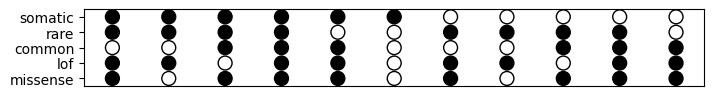

In [17]:
top_10_features_by_rank = extract_top_features_from_df(df_ranks_by_key, top_n=20, keep_smallest_n=True, index_label="rank")

dsets = sorted(top_10_features_by_rank.columns.tolist())[::-1]
display(top_10_features_by_rank[dsets])

# plot feature matrix to accompany the table
features = ['somatic', 'rare', 'common', 'lof', 'missense']
feature_matrix = get_feature_matrix(dsets, features)
plot_feature_matrix(feature_matrix, dsets, fig_size=(8,1))


### Table: OR, mu0 (class 0 = primary = control frequency) for the top N ranked genes from each major dataset group.

In [18]:
def calculate_proportions(somatic_mut, y, gene_list):
    logger.info("Group by class and compute mean proportions")
    # Align y to somatic_mut by index
    y_aligned = y.loc[somatic_mut.index]
    
    # Subset to genes of interest
    gene_df = somatic_mut[gene_list]
    
    # Combine with response variable
    combined = gene_df.copy()
    combined['class'] = y_aligned
    
    # Group by class and compute proportions (mean of binary values)
    proportions = combined.groupby('class').mean().T
    
    return proportions

def calc_OR_from_frequencies(mu1, mu0):
    """
    Calculate odds ratio (OR) from event frequencies in two groups.

    Args:
        mu1 (float): Event frequency in group 1 (e.g., treatment or case group).
        mu0 (float): Event frequency in group 0 (e.g., control group).

    Returns:
        float: Odds ratio (OR) = (mu1 / (1 - mu1)) / (mu0 / (1 - mu0))
    """
    # Convert to Series if needed
    mu1 = pd.Series(mu1)
    mu0 = pd.Series(mu0)
    # Initialize output with NaN
    OR = pd.Series(index=mu1.index, dtype=float)

    odds1 = mu1 / (1 - mu1)
    odds0 = mu0 / (1 - mu0)
    OR = odds1 / odds0
    return OR


def build_modality_stats(modality_dfs: dict[str, pd.DataFrame],
                         y,
                         response_col=None) -> dict[str, pd.DataFrame]:
    """
    For every modality DataFrame, compute:
        • control (class 0) frequency μ0
        • case    (class 1) frequency μ1
        • odds ratio OR = (μ1 / (1-μ1)) ÷ (μ0 / (1-μ0))

    Returns
    -------
    stats_by_modality : dict
        key   = modality name (e.g. 'somatic_mut')
        value = DataFrame with columns
                ['gene', 'mu0', 'mu1', 'odds_ratio']
    """
    # ── 1. Ensure `y_series` is a simple Series ────────────────────────────
    if isinstance(y, pd.DataFrame):
        if response_col is not None:
            y_series = y[response_col]
        elif y.shape[1] == 1:
            y_series = y.iloc[:, 0]
        else:
            raise ValueError(
                "y has multiple columns; please specify `response_col`."
            )
    else:
        y_series = y

    stats_by_modality = {}

    for modality, df_mod in modality_dfs.items():
        # all genes in this modality
        genes = df_mod.columns.tolist()

        # get frequencies by class
        props = calculate_proportions(df_mod, y_series, genes)  # index = gene, cols = {0,1}
        mu0 = props[0]
        mu1 = props[1]

        # Compute OR gene-wise
        OR = calc_OR_from_frequencies(mu1, mu0)

        # Pack into a tidy DataFrame
        stats_by_modality[modality] = (
            pd.DataFrame({
                "gene": props.index,
                "mu0":  mu0.values,
                "mu1":  mu1.values,
                "odds_ratio": OR.values,
            })
            .set_index("gene")          # easier look-ups later
        )

    return stats_by_modality

def annotate_top_features(top_10_features_by_rank: pd.DataFrame,
                          dsets_to_visualize: list[str],
                          modality_stats: dict[str, pd.DataFrame]
                         ) -> dict[str, pd.DataFrame]:
    """
    For each dataset group column requested, return a DataFrame
    (rank 1–10) augmented with μ0, μ1, and OR looked up from the
    modality-specific summaries built in step 1.

    Returns
    -------
    dict
        key   = dataset group name
        value = DataFrame with columns
                ['feature', 'gene', 'modality', 'mu0', 'mu1', 'odds_ratio']
                indexed by rank (1–10)
    """
    annotated = {}

    for dset in dsets_to_visualize:
        feats = top_10_features_by_rank[dset].dropna()
        out_rows = []

        for rank, modality in feats.items():
            # Expect everything before first _ is the gene. Everything after the first _ is the modality name.
            try:
                gene, modality = modality.split("_", 1)
            except ValueError:
                raise ValueError(f"modality name '{modality}' not in gene_modality form")

            # Look up stats
            try:
                stats_row = modality_stats[modality].loc[gene]
            except KeyError:
                raise KeyError(f"Stats not found for {gene} in modality {modality}")

            out_rows.append({
                "modality": modality,
                "gene": gene,
                "modality": modality,
                "mu0": stats_row.mu0,
                "mu1": stats_row.mu1,
                "odds_ratio": stats_row.odds_ratio
            })

        annotated[dset] = pd.DataFrame(out_rows, index=feats.index)

    return annotated


In [66]:
# focus on biggest (least sparse germline dataset) tested
dsets_to_visualize = [
    'somatic_amp somatic_del somatic_mut',
    # 'somatic_amp somatic_del somatic_mut germline_rare_lof',
    # 'germline_rare_lof',
    'germline_rare_common_lof_missense',
    'somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense'
    ]

# focus on biggest (least sparse germline dataset) tested
modalities_to_visualize = [
    'somatic_amp',
    'somatic_del',
    'somatic_mut',
    # 'germline_rare_lof',
    'germline_rare_common_lof_missense',
    ]

In [68]:
importance_path = f'{eval_set}_feature_importances_path' # f'{eval_set}_gene_importances_path
df_feat_imps_by_key, df_feat_ranks_by_key = process_feature_importances(df_filt, response_df, 
                                                              importance_path_column=importance_path, # 
                                                              group_identifier_column="datasets")
N=10
top_N_features_by_rank = extract_top_features_from_df(df_feat_ranks_by_key, top_n=N, keep_smallest_n=True, index_label="rank")

2025-07-30 02:34:52 INFO     [__main__] Processing feature importances for 55 runs...


In [69]:
logger.info("Load the response (aka y) DF")
response_f = "/mnt/disks/gmiller_data1/pnet_germline/data/pnet_database/prostate/processed/response_paper.csv"
response_df = load_response_variable(response_f)

2025-07-30 02:35:32 INFO     [__main__] Load the response (aka y) DF


In [71]:
# For each of the top features, extract the OR and control frequency from the associated modality. 
# E.g., if feature is AR_somatic_mut --> extract OR and control frequency from the somatic_mut DF

logger.info("1. Build modality-level summaries")
input_data_dir = df.input_data_dir.unique()[0]
dset_df_f = [os.path.join(input_data_dir, i+".csv") for i in modalities_to_visualize]
dset_dfs = [pd.read_csv(p, index_col=0) for p in dset_df_f]

named_modality_dfs = dict(zip(modalities_to_visualize, dset_dfs))
modality_stats = build_modality_stats(named_modality_dfs, response_df)

logger.info("2. Annotate each dataset group's top-N table")
annotated_topN = annotate_top_features(top_N_features_by_rank,
                                        dsets_to_visualize,
                                        modality_stats)
for dset in dsets_to_visualize:
    annotated_topN[dset].drop(columns='mu1', inplace=True)
    # annotated_topN[dset].drop(columns='feature', inplace=True)



2025-07-30 02:35:54 INFO     [__main__] 1. Build modality-level summaries
2025-07-30 02:35:57 INFO     [__main__] Group by class and compute mean proportions
2025-07-30 02:35:57 INFO     [__main__] Group by class and compute mean proportions
2025-07-30 02:35:57 INFO     [__main__] Group by class and compute mean proportions
2025-07-30 02:35:57 INFO     [__main__] Group by class and compute mean proportions
2025-07-30 02:35:58 INFO     [__main__] 2. Annotate each dataset group's top-N table


In [81]:
tmp = modality_stats['germline_rare_common_lof_missense'].sort_values(by=["mu0", "odds_ratio"], ascending=[False, False])
# drop rows with missing odds_ratio
tmp = tmp[~tmp['odds_ratio'].isna()]
tmp.style.format({
    "mu0": "{:.3f}",
    "mu1": "{:.3f}",
    "odds_ratio": "{:.2f}"
})

,mu0,mu1,odds_ratio
gene,,,
ECT2L,0.035,0.031,0.87
MUTYH,0.017,0.017,1.01
PMS2,0.015,0.000,0.00
ATM,0.012,0.024,1.97
CHEK2,0.011,0.010,0.96
POLQ,0.009,0.024,2.64
CNBD1,0.009,0.014,1.49
ROS1,0.009,0.003,0.37
HLA-A,0.008,0.027,3.64


In [ ]:
logger.info("Save and display top ranked gene tables with OR and control_freq")
for dset in dsets_to_visualize:
    logger.info(f"\ndset: {dset}")

    # --- rename mu0 -> control_freq (leave all other cols intact) ------------
    df_out = annotated_topN[dset].rename(columns={"mu0": "control_freq"}).round({
    "control_freq": 3,
    "odds_ratio": 2
})

    # --- save to CSV ---------------------------------------------------------
    out_path = os.path.join(
        RESULTS_DIR,
        f"{dset}_top_ranked_genes_with_class_freq_and_odds_ratio.csv"
    )
    logger.info(f"Saving to {out_path}")
    df_out.to_csv(out_path, index_label="rank")

    # --- pretty-print --------------------------------------------------------
    display(
        df_out.style.format({
            "control_freq": "{:.3f}",
            "mu1":          "{:.3f}",
            "odds_ratio":   "{:.2f}"
        }).background_gradient(
    subset=["control_freq"], cmap="Blues"
).background_gradient(
    subset=["odds_ratio"], cmap="OrRd").set_caption(f"Top ranked gene for data combination: {dset}")
    )


2025-06-27 19:34:32 INFO     [__main__] Save and display top ranked gene tables with OR and control_freq
2025-06-27 19:34:32 INFO     [__main__] 
dset: somatic_amp somatic_del somatic_mut
2025-06-27 19:34:32 INFO     [__main__] Saving to ../results/p1000_somatic_germline/somatic_amp somatic_del somatic_mut_top_ranked_genes_with_class_freq_and_odds_ratio.csv


,gene,modality,control_freq,odds_ratio
rank,,,,
1,AR,somatic_amp,0.005,130.55
2,PTEN,somatic_del,0.061,5.28
3,TP53,somatic_mut,0.109,4.32
4,AR,somatic_mut,0.005,34.29
5,OBSCN,somatic_del,0.132,0.07
6,AP2A2,somatic_del,0.124,0.12
7,MED30,somatic_amp,0.018,4.55
8,RBBP5,somatic_amp,0.006,14.49
9,COL1A2,somatic_amp,0.118,0.29


2025-06-27 19:34:32 INFO     [__main__] 
dset: germline_rare_common_lof_missense
2025-06-27 19:34:32 INFO     [__main__] Saving to ../results/p1000_somatic_germline/germline_rare_common_lof_missense_top_ranked_genes_with_class_freq_and_odds_ratio.csv


,gene,modality,control_freq,odds_ratio
rank,,,,
1,BRCA2,germline_rare_common_lof_missense,0.002,35.20
2,ATM,germline_rare_common_lof_missense,0.012,1.97
3,HLA-A,germline_rare_common_lof_missense,0.008,3.64
4,CNBD1,germline_rare_common_lof_missense,0.009,1.49
5,MSH2,germline_rare_common_lof_missense,0.003,0.00
6,SBDS,germline_rare_common_lof_missense,0.006,3.39
7,ERCC2,germline_rare_common_lof_missense,0.005,1.49
8,ECT2L,germline_rare_common_lof_missense,0.035,0.87
9,TET2,germline_rare_common_lof_missense,0.002,6.75


2025-06-27 19:34:32 INFO     [__main__] 
dset: somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense
2025-06-27 19:34:32 INFO     [__main__] Saving to ../results/p1000_somatic_germline/somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense_top_ranked_genes_with_class_freq_and_odds_ratio.csv


,gene,modality,control_freq,odds_ratio
rank,,,,
1,AR,somatic_amp,0.005,130.55
2,PTEN,somatic_del,0.061,5.28
3,TP53,somatic_mut,0.109,4.32
4,AR,somatic_mut,0.005,34.29
5,AP2A2,somatic_del,0.124,0.12
6,OBSCN,somatic_del,0.132,0.07
7,COL1A2,somatic_amp,0.118,0.29
8,MAML3,somatic_amp,0.015,2.99
9,MED30,somatic_amp,0.018,4.55


### BRCA2 rank trajectory

In [ ]:
# For a single gene, extract importances and ranks from the processed dicts for


def get_single_gene_info(df_imps_by_key, df_ranks_by_key, gene_name, group_identifier_col="group_identifier"):
    records = []

    for key, df_imp in df_imps_by_key.items():
        mean_imp = df_imp.mean()
        mean_rank = df_ranks_by_key[key].mean()
        recomputed_mean   = mean_rank.rank(ascending=True)    # 1 = best, 2 = next…

        
        matches = mean_imp[mean_imp.index.str.startswith(gene_name)]

        for match_name in matches.index:
            records.append({
                group_identifier_col: key,
                "gene_name": gene_name,
                "gene_name_group": match_name,
                "importance": mean_imp[match_name],
                "absolute_importance": abs(mean_imp[match_name]),
                "rank": recomputed_mean[match_name]
            })

    return pd.DataFrame(records)
# Merge AR stats into the plotting dataframe
df_BRCA2 = get_single_gene_info(df_imps_by_key, df_ranks_by_key, gene_name = "BRCA2", group_identifier_col="datasets")
df_plot = df.merge(df_BRCA2, on="datasets", how="left")
df_plot_avg = df_plot.groupby("datasets", as_index=False).mean()

In [ ]:
df_BRCA2[df_BRCA2["datasets"] == "somatic_amp somatic_del somatic_mut"]

,datasets,gene_name,gene_name_group,importance,absolute_importance,rank
11,somatic_amp somatic_del somatic_mut,BRCA2,BRCA2,0.008292,0.008292,388.0


In [ ]:
df_BRCA2["gene_name_group"].unique()

array(['BRCA2'], dtype=object)

In [ ]:
# df_BRCA2.sort_values(by="rank", ascending=True)
# df_BRCA2[(df_BRCA2["gene_name_group"].str.contains("germline")) | (df_BRCA2["datasets"] == "somatic_amp somatic_del somatic_mut")].sort_values(by=["absolute_importance", "rank"], ascending=[False, True])[["datasets", "gene_name_group", "rank", "absolute_importance"]].style.format({
#     "importance": "{:.2f}",
#     "absolute_importance": "{:.4f}",
#     "rank": "{:.2f}"
# })

logger.info("Any combo of germline only that has rare_lof ranks BRCA2 highly")
df_BRCA2.sort_values(by=["rank", "absolute_importance"], ascending=[True, False])[["datasets", "gene_name_group", "rank", "absolute_importance", "importance"]].style.format({
    "importance": "{:.4f}",
    "absolute_importance": "{:.4f}",
    "rank": "{:.2f}"
})

2025-06-26 22:42:30 INFO     [__main__] Any combo of germline only that has rare_lof ranks BRCA2 highly


,datasets,gene_name_group,rank,absolute_importance,importance
10,germline_rare_lof,BRCA2,1.00,0.0166,0.0166
8,germline_rare_lof_missense,BRCA2,1.00,0.0155,0.0155
5,germline_rare_common_lof_missense,BRCA2,1.00,0.0121,0.0121
12,germline_rare_common_lof,BRCA2,1.00,0.0092,0.0092
6,somatic_amp somatic_del somatic_mut germline_rare_lof,BRCA2,23.00,0.0315,0.0315
3,somatic_amp somatic_del somatic_mut germline_rare_lof_missense,BRCA2,59.50,0.0214,0.0214
1,somatic_amp somatic_del somatic_mut germline_rare_common_lof,BRCA2,78.00,0.0221,0.0221
4,somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense,BRCA2,105.00,0.0339,0.0339
0,somatic_amp somatic_del somatic_mut germline_rare_common_missense,BRCA2,157.00,0.0084,0.0084
2,somatic_amp somatic_del somatic_mut germline_common_lof_missense,BRCA2,180.00,0.0114,0.0114


## check for unintentional pathogenic germline dataset equality
There are no common LOF variants. As a consequence of that, I expect that:
1. germline_common_lof_missense == germline_common_missense
2. germline_rare_common_lof == germline_rare_lof

However, I have included these potentially duplicate germline datasets in my P-NET testing. They do show somewhat different results (though nothing statistically significant). 

If these DFs contain identical information, then I should exclude (or lump?) these runs together.


In [ ]:
input_data_dir = "/mnt/disks/gmiller_data1/pnet_germline/processed/wandb-group-data_prep_germline_tier12_and_somatic/converted-IDs-to-somatic_imputed-germline_True_imputed-somatic_False_paired-samples-True/wandb-run-id-u5yt90p1"
#1. 
germline_common_lof_missense_df = pd.read_csv(os.path.join(input_data_dir, "germline_common_lof_missense.csv"), index_col=0)
germline_common_missense_df = pd.read_csv(os.path.join(input_data_dir, "germline_common_missense.csv"), index_col=0)
# 2.
germline_rare_common_lof_df = pd.read_csv(os.path.join(input_data_dir, "germline_rare_common_lof.csv"), index_col=0)
germline_rare_lof_df = pd.read_csv(os.path.join(input_data_dir, "germline_rare_lof.csv"), index_col=0)

In [ ]:
# Sort both DataFrames by columns and rows (for consistent order)
def normalize_df(df):
    # Sort columns alphabetically
    df = df.sort_index(axis=1)
    # Sort rows based on all column values
    return df.sort_values(by=list(df.columns)).reset_index(drop=True)

# Normalize both DataFrames
# 1.
df1_normalized = normalize_df(germline_common_lof_missense_df)
df2_normalized = normalize_df(germline_common_missense_df)
# 2.
df1_normalized = normalize_df(germline_rare_common_lof_df)
df2_normalized = normalize_df(germline_rare_lof_df)

# Check for equality
are_equal = df1_normalized.equals(df2_normalized)
print(are_equal)

True


Result: I do have accidentally duplicate DF inputs (since no pathogenic common LOF variants)